In [314]:
"""
DLT Camera Calibration — Input Data
====================================

Synthetic data generated from known ground truth (K, R, t).
Your job: recover P, then (K, R, t), from `X_world` and `x_noisy` only.
Do NOT use K_true, R_true, t_true, P_true inside your DLT pipeline —
they are here only for (a) generating the data and (b) final verification.

Noise model:  i.i.d. Gaussian, sigma = 0.5 px in image space (realistic
              for a calibrated industrial camera).
Configuration: 12 non-coplanar world points (unit cube corners + 4 interior).
              Camera at ~(0.5, -0.3, 5.0) looking roughly along +z with a
              30° yaw + 15° pitch.  Image sensor implicitly ~640x480.
"""

import numpy as np

np.random.seed(42)

# ---------------------------------------------------------------------------
# GROUND TRUTH (do not use inside the DLT pipeline; verification only)
# ---------------------------------------------------------------------------
K_true = np.array([
    [820.0,   0.0, 325.0],
    [  0.0, 780.0, 245.0],
    [  0.0,   0.0,   1.0],
])

theta_y = np.deg2rad(30.0)
theta_x = np.deg2rad(15.0)
Ry = np.array([
    [ np.cos(theta_y), 0.0, np.sin(theta_y)],
    [             0.0, 1.0,             0.0],
    [-np.sin(theta_y), 0.0, np.cos(theta_y)],
])
Rx = np.array([
    [1.0,             0.0,              0.0],
    [0.0, np.cos(theta_x), -np.sin(theta_x)],
    [0.0, np.sin(theta_x),  np.cos(theta_x)],
])
R_true = Rx @ Ry                          # world -> camera rotation
t_true = np.array([0.5, -0.3, 5.0])       # world origin in camera frame
C_true = -R_true.T @ t_true               # camera centre in world coords

P_true = K_true @ np.hstack([R_true, t_true.reshape(3, 1)])  # 3x4

# ---------------------------------------------------------------------------
# YOUR INPUT #1:  world points (12 x 3), non-coplanar
# ---------------------------------------------------------------------------
X_world = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [1.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [0.5, 0.5, 0.5],
    [0.3, 0.7, 0.2],
    [0.8, 0.2, 0.6],
    [0.5, 0.1, 0.9],
])

# ---------------------------------------------------------------------------
# YOUR INPUT #2:  noisy image points (12 x 2), in pixels
# ---------------------------------------------------------------------------
X_h = np.hstack([X_world, np.ones((len(X_world), 1))])          # (12, 4)
x_h = (P_true @ X_h.T).T                                         # (12, 3)
x_pixels_clean = x_h[:, :2] / x_h[:, 2:]                         # (12, 2)
x_noisy = x_pixels_clean + np.random.randn(*x_pixels_clean.shape) * 0.5


if __name__ == "__main__":
    print(f"X_world.shape  = {X_world.shape}")
    print(f"x_noisy.shape  = {x_noisy.shape}")
    print(f"pixel range u: [{x_noisy[:, 0].min():.1f}, {x_noisy[:, 0].max():.1f}]")
    print(f"pixel range v: [{x_noisy[:, 1].min():.1f}, {x_noisy[:, 1].max():.1f}]")
    print(f"\nGround truth P (unit Frobenius):\n{P_true / np.linalg.norm(P_true)}")
    print(f"\nGround truth camera centre C = {C_true}")
    print(f"Sanity: P @ [C; 1] = {P_true @ np.append(C_true, 1.0)}   (should be ~0)")

X_world.shape  = (12, 3)
x_noisy.shape  = (12, 2)
pixel range u: [402.8, 610.6]
pixel range v: [175.2, 375.3]

Ground truth P (unit Frobenius):
[[ 2.15818828e-01  3.28173956e-02  2.66026378e-01  7.93942287e-01]
 [-6.78322681e-03  3.18682118e-01  1.17488935e-02  3.86632337e-01]
 [-1.88424904e-04  1.00976602e-04  3.26361507e-04  1.95071815e-03]]

Ground truth camera centre C = [ 2.02062472 -1.00431748 -4.49982468]
Sanity: P @ [C; 1] = [-2.27373675e-13  1.13686838e-13  0.00000000e+00]   (should be ~0)


In [315]:
P_final_norm = P_final / np.linalg.norm(P_final)
P_true_norm  = P_true  / np.linalg.norm(P_true)
if P_final_norm.flatten() @ P_true_norm.flatten() < 0:
    P_final_norm = -P_final_norm

In [316]:
print(P_true_norm.T)
print(P_final_norm.T)

[[ 2.15818828e-01 -6.78322681e-03 -1.88424904e-04]
 [ 3.28173956e-02  3.18682118e-01  1.00976602e-04]
 [ 2.66026378e-01  1.17488935e-02  3.26361507e-04]
 [ 7.93942287e-01  3.86632337e-01  1.95071815e-03]]
[[-8.57544890e-02 -7.80211818e-03 -1.90846083e-04]
 [ 4.01939563e-02  3.06993474e-01  8.94514294e-05]
 [ 1.43868849e-01  1.10006782e-02  3.20179210e-04]
 [ 8.56143628e-01  3.78047349e-01  1.90533953e-03]]


In [317]:
#extra channel for noisy

x_noisy3 = np.hstack([x_noisy, np.ones((len(x_noisy),1))])
x_noisy3

array([[407.24835708, 198.13086785,   1.        ],
       [573.30516688, 216.30402546,   1.        ],
       [402.84719561, 343.65456448,   1.        ],
       [560.33202145, 375.27908166,   1.        ],
       [465.26003012, 175.22397855,   1.        ],
       [610.5860872 , 187.25527954,   1.        ],
       [459.65008463, 300.57674282,   1.        ],
       [596.77462079, 324.10228279,   1.        ],
       [507.31235026, 265.08945796,   1.        ],
       [460.03755407, 299.77689209,   1.        ],
       [562.62866794, 224.0903144 ,   1.        ],
       [529.84072037, 196.3330741 ,   1.        ]])

In [318]:
X_world3 = np.hstack([X_world, np.ones((len(X_world),1))])
X_world3

array([[0. , 0. , 0. , 1. ],
       [1. , 0. , 0. , 1. ],
       [0. , 1. , 0. , 1. ],
       [1. , 1. , 0. , 1. ],
       [0. , 0. , 1. , 1. ],
       [1. , 0. , 1. , 1. ],
       [0. , 1. , 1. , 1. ],
       [1. , 1. , 1. , 1. ],
       [0.5, 0.5, 0.5, 1. ],
       [0.3, 0.7, 0.2, 1. ],
       [0.8, 0.2, 0.6, 1. ],
       [0.5, 0.1, 0.9, 1. ]])

In [319]:
x_noisy3

array([[407.24835708, 198.13086785,   1.        ],
       [573.30516688, 216.30402546,   1.        ],
       [402.84719561, 343.65456448,   1.        ],
       [560.33202145, 375.27908166,   1.        ],
       [465.26003012, 175.22397855,   1.        ],
       [610.5860872 , 187.25527954,   1.        ],
       [459.65008463, 300.57674282,   1.        ],
       [596.77462079, 324.10228279,   1.        ],
       [507.31235026, 265.08945796,   1.        ],
       [460.03755407, 299.77689209,   1.        ],
       [562.62866794, 224.0903144 ,   1.        ],
       [529.84072037, 196.3330741 ,   1.        ]])

In [320]:
#lets create  A

def getA(x_noisy3, X_world3):
    
    A= np.zeros((24,12))
    
    for i in range(12):
        k = 2*i
        A[k][4:8] = -x_noisy3[i][2]*X_world3[i]
        A[k][8:12] = x_noisy3[i][1]* X_world3[i]
        A[k+1][:4] = X_world3[i] 
        A[k+1][8:12] = -x_noisy3[i][0]* X_world3[i]
    return A
A = getA(x_noisy3, X_world3)

In [321]:
U,S,Vt=  np.linalg.svd(A, full_matrices=False)

In [322]:
#now lets check the quality of sigma 
#the quality not the best
#harley normalization will be needed 

In [323]:
#check the cliff r
r = -999999
the_cliff  = -1
for i in range(11):
    if(S[i]/S[i+1]>r):
        r= S[i]/S[i+1]
        the_cliff = i
    print(i)
    print(S[i]/S[i+1])


    

0
3.0210659001615023
1
1.1126399391289818
2
1.434324545163732
3
125.85788702505934
4
2.780588819387847
5
1.15427546067675
6
1.3614373424279875
7
4.088299487433529
8
1.3295196890728882
9
1.0946272026165997
10
51.09127422670247


In [324]:

#Hartley Normalization - translation
tw_norm_vec = -np.mean(X_world3,axis=0)
tw_norm_vec[3] = 0
tw_norm_vec

tc_norm_vec = -np.mean(x_noisy3,axis=0)
tc_norm_vec[2] =0


In [325]:
#Hartley Normalisation - scaling
centered_w  = X_world3 +tw_norm_vec[:]
sw_norm = np.sqrt(3)/np.mean(np.linalg.norm(centered_w, axis=1))


centered_c = x_noisy3 +tc_norm_vec[:]
sc_norm = np.sqrt(2)/ np.mean(np.linalg.norm(centered_c, axis=1))


In [326]:
# putting it together S and t

T_ = np.eye(3)
T_[:,-1] = tc_norm_vec
T_[2,2]=1
print(T_)

U_ = np.eye(4)
U_[:,-1] = tw_norm_vec
U_[3,3]= 1
print(U_)

s_c = np.diag([sc_norm, sc_norm,1])
s_w = np.diag([sw_norm, sw_norm, sw_norm,1])



[[   1.            0.         -511.31857137]
 [   0.            1.         -258.81804681]
 [   0.            0.            1.        ]]
[[ 1.          0.          0.         -0.50833333]
 [ 0.          1.          0.         -0.45833333]
 [ 0.          0.          1.         -0.51666667]
 [ 0.          0.          0.          1.        ]]


In [327]:
#multiplication camera T
T = s_c @T_
T

array([[ 0.01613446,  0.        , -8.24984758],
       [ 0.        ,  0.01613446, -4.17588869],
       [ 0.        ,  0.        ,  1.        ]])

In [328]:
#multiplication world U
U = s_w @ U_
U

array([[ 1.39572364,  0.        ,  0.        , -0.70949285],
       [ 0.        ,  1.39572364,  0.        , -0.63970667],
       [ 0.        ,  0.        ,  1.39572364, -0.72112388],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [329]:
#now we want to get P' to then get P out of this 

# so for that we have 

new_x_c = T @x_noisy3.T
new_x_c = new_x_c.T
print(new_x_c)

new_X_w = U @ X_world3.T
new_X_w = new_X_w.T
print(new_X_w)

[[-1.67911641 -0.97915469  1.        ]
 [ 1.00012007 -0.68594066  1.        ]
 [-1.75012676  1.36879116  1.        ]
 [ 0.79080541  1.87903558  1.        ]
 [-0.74312956 -1.34874491  1.        ]
 [ 1.60162748 -1.1546264   1.        ]
 [-0.83364299  0.67375389  1.        ]
 [ 1.37878697  1.05332571  1.        ]
 [-0.0646382   0.10118581  1.        ]
 [-0.82739138  0.66084873  1.        ]
 [ 0.82786055 -0.56031311  1.        ]
 [ 0.29884482 -1.00816111  1.        ]]
[[-0.70949285 -0.63970667 -0.72112388  1.        ]
 [ 0.68623079 -0.63970667 -0.72112388  1.        ]
 [-0.70949285  0.75601697 -0.72112388  1.        ]
 [ 0.68623079  0.75601697 -0.72112388  1.        ]
 [-0.70949285 -0.63970667  0.67459976  1.        ]
 [ 0.68623079 -0.63970667  0.67459976  1.        ]
 [-0.70949285  0.75601697  0.67459976  1.        ]
 [ 0.68623079  0.75601697  0.67459976  1.        ]
 [-0.01163103  0.05815515 -0.02326206  1.        ]
 [-0.29077576  0.33729988 -0.44197915  1.        ]
 [ 0.40708606 -0.3605

In [330]:
A_2 = getA(new_x_c,new_X_w)


In [331]:
U_2,S_2, Vt_2 = np.linalg.svd(A_2, full_matrices=False)


In [332]:
T_inv = np.linalg.inv(T)

T_inv

array([[ 61.97915372,   0.        , 511.31857137],
       [  0.        ,  61.97915372, 258.81804681],
       [  0.        ,   0.        ,   1.        ]])

In [333]:
Vt_2[:,-1]

array([ 8.91189881e-01,  2.27601040e-01,  7.93632772e-02, -7.16796742e-02,
       -3.02993347e-02,  2.03622217e-02,  5.48833634e-02,  3.87442988e-04,
       -7.07798766e-03, -1.75197440e-02, -6.18662244e-03, -3.71216298e-01])

In [334]:
U

array([[ 1.39572364,  0.        ,  0.        , -0.70949285],
       [ 0.        ,  1.39572364,  0.        , -0.63970667],
       [ 0.        ,  0.        ,  1.39572364, -0.72112388],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [335]:
P_hat = Vt_2[-1].reshape((3,4))
P_hat

array([[-0.64755809,  0.04002267, -0.20368273,  0.00694961],
       [-0.08864816, -0.60476051,  0.15310784,  0.00225684],
       [ 0.02528806, -0.01325884, -0.04329036, -0.3712163 ]])

In [336]:
#to get p
P_final = T_inv @ P_hat @ U 

In [337]:
M = P_final[:,:3]


In [338]:
from scipy.linalg import rq

In [353]:
K,R = rq(M)

In [354]:
K

array([[-57.25683777,  -0.07491376,  23.51687003],
       [  0.        ,  54.48945114,  17.3131636 ],
       [  0.        ,   0.        ,   0.07238059]])

In [355]:
K

array([[-57.25683777,  -0.07491376,  23.51687003],
       [  0.        ,  54.48945114,  17.3131636 ],
       [  0.        ,   0.        ,   0.07238059]])

In [357]:
D = np.diag(np.sign(np.diag(K)))
K = K @ D
R = D @ R
K = K / K[2,2]

In [358]:
K

array([[791.05234169,  -1.03499785, 324.90573753],
       [  0.        , 752.81852098, 239.19621025],
       [  0.        ,   0.        ,   1.        ]])

In [359]:
R


array([[-0.863611  , -0.00104664, -0.50415765],
       [-0.12802518, -0.96676308,  0.22131133],
       [ 0.48763264, -0.25567178, -0.83477324]])

In [360]:
P_final.T

array([[-3.79704510e+01,  1.46644199e+00,  3.52951395e-02],
       [-6.00010322e+00, -5.71048767e+01, -1.85056748e-02],
       [-4.85143059e+01, -2.39343252e+00, -6.04213820e-02],
       [-1.42261639e+02, -6.92733661e+01, -3.49458513e-01]])

In [361]:
# Check P quality — reprojection error
for i in range(12):
    x_proj = P_final @ X_world3[i]
    x_proj = x_proj[:2] / x_proj[2]
    err = np.linalg.norm(x_proj - x_noisy[i])
    print(f"Point {i}: reproj error = {err:.3f} px")

Point 0: reproj error = 0.186 px
Point 1: reproj error = 0.607 px
Point 2: reproj error = 0.216 px
Point 3: reproj error = 0.559 px
Point 4: reproj error = 0.418 px
Point 5: reproj error = 0.173 px
Point 6: reproj error = 0.307 px
Point 7: reproj error = 0.475 px
Point 8: reproj error = 0.541 px
Point 9: reproj error = 0.665 px
Point 10: reproj error = 0.727 px
Point 11: reproj error = 0.611 px


In [362]:
P_final.T

array([[-3.79704510e+01,  1.46644199e+00,  3.52951395e-02],
       [-6.00010322e+00, -5.71048767e+01, -1.85056748e-02],
       [-4.85143059e+01, -2.39343252e+00, -6.04213820e-02],
       [-1.42261639e+02, -6.92733661e+01, -3.49458513e-01]])

In [363]:
P_final_norm = P_final / np.linalg.norm(P_final)
P_true_norm  = P_true  / np.linalg.norm(P_true)
if P_final_norm.flatten() @ P_true_norm.flatten() < 0:
    P_final_norm = -P_final_norm

In [364]:
print(P_true_norm.T)
print(P_final_norm.T)

[[ 2.15818828e-01 -6.78322681e-03 -1.88424904e-04]
 [ 3.28173956e-02  3.18682118e-01  1.00976602e-04]
 [ 2.66026378e-01  1.17488935e-02  3.26361507e-04]
 [ 7.93942287e-01  3.86632337e-01  1.95071815e-03]]
[[ 2.11806574e-01 -8.18009917e-03 -1.96883166e-04]
 [ 3.34697449e-02  3.18542130e-01  1.03228260e-04]
 [ 2.70622252e-01  1.33510330e-02  3.37042242e-04]
 [ 7.93563140e-01  3.86420334e-01  1.94934768e-03]]


In [366]:


#check the cliff r
r = -999999
the_cliff  = -1
for i in range(11):
    if(S_2[i]/S_2[i+1]>r):
        r= S_2[i]/S_2[i+1]
        the_cliff = i
    print(i)
    print(S_2[i]/S_2[i+1])


    

0
1.2175358726621566
1
1.07260890844716
2
1.4711782267121927
3
1.2630075195753803
4
1.0894445938175568
5
1.0191997740237773
6
1.0643503119978075
7
1.0078586723666199
8
1.0166025423209635
9
1.011992257655536
10
192.96962634200014


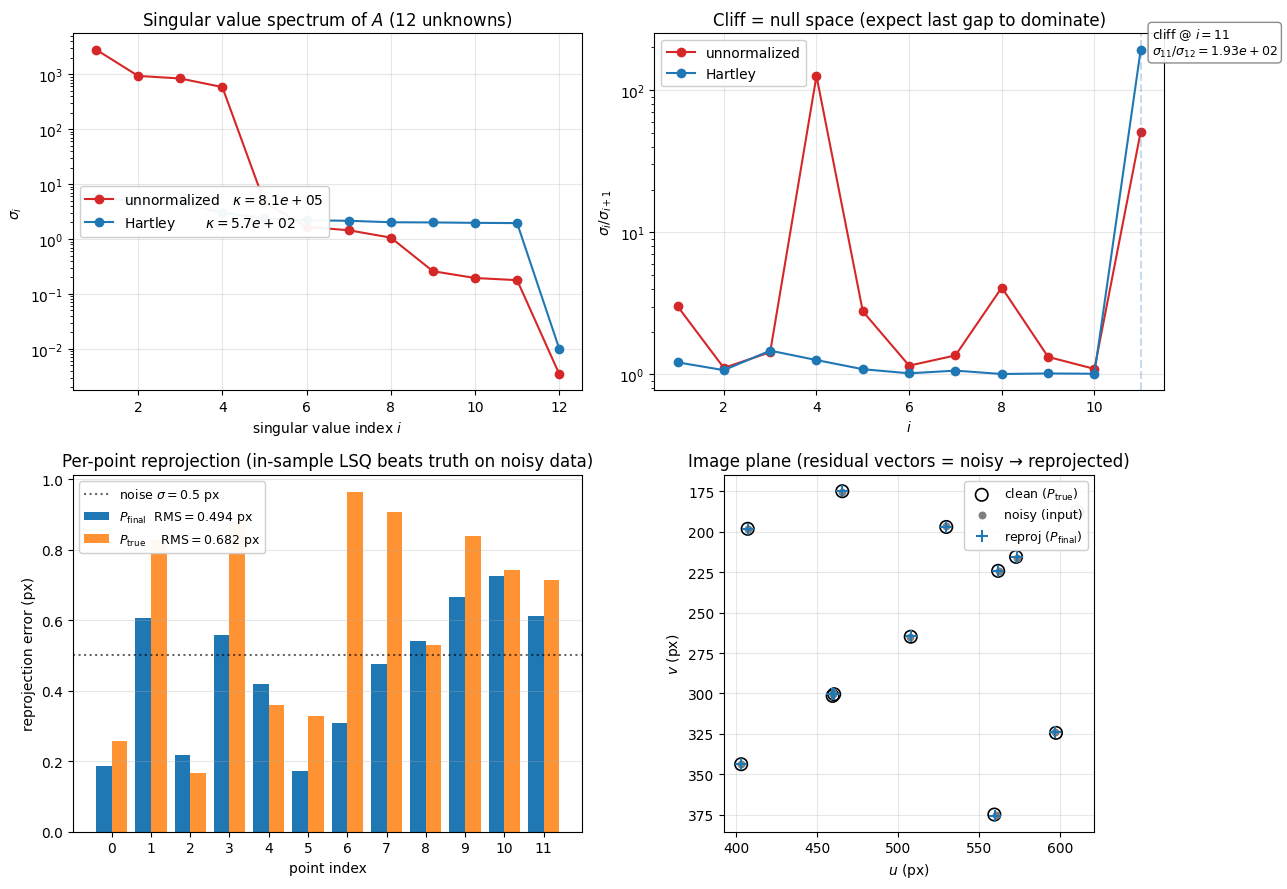

In [368]:

import matplotlib.pyplot as plt

# -- recompute what we need (robust to kernel state) -----------------
_, S_unnorm, _ = np.linalg.svd(getA(x_noisy3, X_world3), full_matrices=False)
_, S_norm,   _ = np.linalg.svd(getA(new_x_c,  new_X_w),  full_matrices=False)

def project(P, Xh):
    p = P @ Xh.T                       # (3, N)
    return (p[:2] / p[2:]).T           # (N, 2)

x_clean    = project(P_true,  X_world3)
proj_final = project(P_final, X_world3)
proj_true  = project(P_true,  X_world3)
err_final = np.linalg.norm(proj_final - x_noisy, axis=1)
err_true  = np.linalg.norm(proj_true  - x_noisy, axis=1)

# -- figure ----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Singular value spectrum
ax = axes[0, 0]
idx = np.arange(1, 13)
ax.semilogy(idx, S_unnorm, 'o-', color='tab:red',
            label=fr'unnormalized   $\kappa={S_unnorm[0]/S_unnorm[-1]:.1e}$', lw=1.5)
ax.semilogy(idx, S_norm,   'o-', color='tab:blue',
            label=fr'Hartley       $\kappa={S_norm[0]/S_norm[-1]:.1e}$', lw=1.5)
ax.set_xlabel(r'singular value index $i$')
ax.set_ylabel(r'$\sigma_i$')
ax.set_title(r'Singular value spectrum of $A$ (12 unknowns)')
ax.legend(loc='center left', framealpha=0.95)
ax.grid(True, alpha=0.3)

# (2) Ratios sigma_i / sigma_{i+1} -- the cliff diagnostic
ax = axes[0, 1]
r_un, r_no = S_unnorm[:-1]/S_unnorm[1:], S_norm[:-1]/S_norm[1:]
xi = np.arange(1, 12)
ax.semilogy(xi, r_un, 'o-', color='tab:red',  label='unnormalized', lw=1.5)
ax.semilogy(xi, r_no, 'o-', color='tab:blue', label='Hartley',      lw=1.5)
i_cliff = int(np.argmax(r_no)) + 1
ax.axvline(i_cliff, color='tab:blue', alpha=0.25, ls='--')
ax.annotate(fr'cliff @ $i={i_cliff}$' + '\n'
            + fr'$\sigma_{{{i_cliff}}}/\sigma_{{{i_cliff+1}}}={r_no.max():.2e}$',
            xy=(i_cliff, r_no.max()), xytext=(8, -4),
            textcoords='offset points', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))
ax.set_xlabel(r'$i$')
ax.set_ylabel(r'$\sigma_i / \sigma_{i+1}$')
ax.set_title(r'Cliff = null space (expect last gap to dominate)')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)

# (3) Per-point reprojection error
ax = axes[1, 0]
i = np.arange(12); w = 0.4
ax.bar(i - w/2, err_final, w, color='tab:blue',
       label=fr'$P_\mathrm{{final}}$  RMS$={np.sqrt((err_final**2).mean()):.3f}$ px')
ax.bar(i + w/2, err_true,  w, color='tab:orange', alpha=0.85,
       label=fr'$P_\mathrm{{true}}$    RMS$={np.sqrt((err_true**2).mean()):.3f}$ px')
ax.axhline(0.5, color='k', ls=':', alpha=0.6, label=r'noise $\sigma=0.5$ px')
ax.set_xticks(i)
ax.set_xlabel('point index')
ax.set_ylabel('reprojection error (px)')
ax.set_title('Per-point reprojection (in-sample LSQ beats truth on noisy data)')
ax.legend(loc='upper left', framealpha=0.95, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# (4) Image-plane: clean / noisy / reprojected, residual vectors
ax = axes[1, 1]
ax.scatter(x_clean[:, 0],    x_clean[:, 1],    s=80, marker='o',
           edgecolor='k', facecolor='none', lw=1.2, label='clean ($P_\\mathrm{true}$)', zorder=3)
ax.scatter(x_noisy[:, 0],    x_noisy[:, 1],    s=22, c='tab:gray',
           label='noisy (input)', zorder=4)
ax.scatter(proj_final[:, 0], proj_final[:, 1], s=80, marker='+',
           c='tab:blue', lw=1.5, label='reproj ($P_\\mathrm{final}$)', zorder=5)
for k in range(12):
    ax.plot([x_noisy[k, 0], proj_final[k, 0]],
            [x_noisy[k, 1], proj_final[k, 1]], '-', color='tab:blue', alpha=0.4, lw=0.8)
ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_xlabel(r'$u$ (px)')
ax.set_ylabel(r'$v$ (px)')
ax.set_title('Image plane (residual vectors = noisy → reprojected)')
ax.legend(loc='upper right', framealpha=0.95, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()